# Neural SDE: три домена

В этом ноутбуке код из `NeuralSDE.ipynb` перенесен в прикладной формат и запущен для трех временных рядов:

1. акции Apple (`AAPL`),
2. потребление электроэнергии (`UCI Household Electric Power Consumption`),
3. данные CGM о скачках глюкозы/инсулина из XML-файлов в `kt3/data`.

Во всех трех экспериментах задача приводится к one-step forecasting: по окну прошлых значений и дополнительному контексту прогнозируется следующее значение. Neural SDE обучается через дискретизацию Эйлера-Маруямы и ELBO-подобную функцию потерь с KL-регуляризацией.

In [4]:

%pip install yfinance ucimlrepo statsmodels scikit-learn tqdm matplotlib pandas numpy torch

  Using cached beautifulsoup4-4.14.3-py3-none-any.whl.metadata (3.8 kB)
  Using cached websockets-16.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (6.8 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached markupsafe-3.0.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (2.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 4.1 MB/s eta 0:00:00 0:00:01
  

In [5]:
import warnings
from pathlib import Path
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import yfinance as yf
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

T = 1.0
N_STEPS = 64
DT = T / N_STEPS
SQRT_DT = DT ** 0.5
LR = 1e-3
OBS_STD = 0.10

# Для быстрой проверки можно уменьшить, для итогового эксперимента увеличить до 3000-5000.
N_ITER_FINANCE = 1800
N_ITER_ENERGY = 1800
N_ITER_INSULIN = 1800
BATCH_SIZE = 128
M_PRED = 64
TRAIN_RATIO = 0.8

Device: cpu


## Общий код Neural SDE

Сохраняем идею из исходного ноутбука: дрейф параметризуется нейросетью, процесс симулируется методом Эйлера-Маруямы, а KL-регуляризация штрафует слишком большой дрейф.

In [7]:
class ConditionalDrift1D(nn.Module):
    def __init__(self, ctx_dim, hidden=96, activation="tanh"):
        super().__init__()
        act = nn.Tanh if activation == "tanh" else nn.SiLU
        self.net = nn.Sequential(
            nn.Linear(ctx_dim + 1, hidden),
            act(),
            nn.Linear(hidden, hidden),
            act(),
            nn.Linear(hidden, hidden // 2),
            act(),
            nn.Linear(hidden // 2, 1),
        )

    def forward(self, x, ctx):
        z = torch.cat([x, ctx], dim=-1)
        return self.net(z)


def simulate_sde_1d(net, ctx, n_steps=N_STEPS, dt=DT):
    B = ctx.shape[0]
    X = torch.zeros(B, 1, device=ctx.device)
    kl = torch.zeros(B, device=ctx.device)
    sqrt_dt = dt ** 0.5

    for _ in range(n_steps):
        drift = net(X, ctx)
        kl = kl + 0.5 * (drift ** 2).squeeze(-1) * dt
        X = X + drift * dt + sqrt_dt * torch.randn_like(X)

    return X.squeeze(-1), kl


def nsde_loss(net, ctx, y, obs_std=OBS_STD, beta=0.01):
    x_t, kl = simulate_sde_1d(net, ctx)
    log_like = -0.5 / obs_std ** 2 * (x_t - y) ** 2
    elbo = (log_like - beta * kl).mean()
    return -elbo


def train_nsde(X_train, y_train, hidden=96, activation="tanh", n_iter=1800, lr=1e-3,
               batch_size=128, obs_std=OBS_STD, beta_max=0.03):
    net = ConditionalDrift1D(X_train.shape[1], hidden=hidden, activation=activation).to(DEVICE)
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_iter, eta_min=lr * 0.05)
    losses = []

    for it in tqdm(range(1, n_iter + 1)):
        idx = np.random.randint(0, len(X_train), size=batch_size)
        xb = torch.tensor(X_train[idx], dtype=torch.float32, device=DEVICE)
        yb = torch.tensor(y_train[idx], dtype=torch.float32, device=DEVICE)

        beta = min(beta_max, max(0.0, (it - n_iter * 0.2) / (n_iter * 0.4) * beta_max))
        loss = nsde_loss(net, xb, yb, obs_std=obs_std, beta=beta)

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), 5.0)
        opt.step()
        scheduler.step()
        losses.append(loss.item())

    return net, losses


def predict_nsde(net, X_test, scaler_y, m_pred=M_PRED):
    net.eval()
    ctx = torch.tensor(X_test, dtype=torch.float32, device=DEVICE)
    preds = []
    with torch.no_grad():
        for _ in range(m_pred):
            x_t, _ = simulate_sde_1d(net, ctx)
            preds.append(x_t.cpu().numpy())

    pred_s = np.stack(preds)
    mean_s = pred_s.mean(axis=0)
    std_s = pred_s.std(axis=0)

    mean = scaler_y.inverse_transform(mean_s.reshape(-1, 1)).ravel()
    lo = scaler_y.inverse_transform((mean_s - std_s).reshape(-1, 1)).ravel()
    hi = scaler_y.inverse_transform((mean_s + std_s).reshape(-1, 1)).ravel()
    return mean, lo, hi


def rmse(a, b):
    a, b = np.asarray(a), np.asarray(b)
    n = min(len(a), len(b))
    return np.sqrt(np.mean((a[:n] - b[:n]) ** 2))


def mae(a, b):
    a, b = np.asarray(a), np.asarray(b)
    n = min(len(a), len(b))
    return np.mean(np.abs(a[:n] - b[:n]))


def mape(a, b):
    a, b = np.asarray(a), np.asarray(b)
    n = min(len(a), len(b))
    return np.mean(np.abs((a[:n] - b[:n]) / (np.abs(a[:n]) + 1e-8))) * 100


def print_metrics(y_true, predictions):
    rows = []
    for name, pred in predictions.items():
        rows.append({"model": name, "RMSE": rmse(y_true, pred), "MAE": mae(y_true, pred), "MAPE%": mape(y_true, pred)})
    table = pd.DataFrame(rows).sort_values("RMSE")
    display(table)
    return table


def plot_experiment(title, losses, y_true, predictions, ci=None, plot_n=150, ylabel="value"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(title, fontsize=14)

    axes[0].plot(losses, lw=0.6, alpha=0.35)
    if len(losses) >= 50:
        w = max(20, len(losses) // 50)
        smoothed = np.convolve(losses, np.ones(w) / w, mode="valid")
        axes[0].plot(np.arange(w - 1, len(losses)), smoothed, lw=2)
    axes[0].set_title("Обучение Neural SDE")
    axes[0].set_xlabel("Итерация")
    axes[0].set_ylabel("Loss")

    n = min(plot_n, len(y_true))
    x = np.arange(n)
    axes[1].plot(x, y_true[:n], label="Факт", color="black", lw=1.5)
    for name, pred in predictions.items():
        axes[1].plot(x, np.asarray(pred)[:n], label=name, lw=1.3, alpha=0.9)
    if ci is not None:
        lo, hi = ci
        axes[1].fill_between(x, lo[:n], hi[:n], alpha=0.18, label="±1σ SDE")
    axes[1].set_title("Прогноз")
    axes[1].set_xlabel("Шаг теста")
    axes[1].set_ylabel(ylabel)
    axes[1].legend(fontsize=8)

    names = list(predictions.keys())
    vals = [rmse(y_true, predictions[name]) for name in names]
    bars = axes[2].bar(names, vals, width=0.55)
    for b, v in zip(bars, vals):
        axes[2].text(b.get_x() + b.get_width() / 2, v, f"{v:.4g}", ha="center", va="bottom")
    axes[2].set_title("RMSE")
    axes[2].tick_params(axis="x", rotation=20)

    plt.tight_layout()
    plt.show()

## Эксперимент 1: акции Apple

Используем `AAPL` как целевой ряд, а `QQQ`, `VIX`, объемы и скользящие статистики как рыночный контекст. Целевая переменная - следующая лог-доходность Apple.

In [8]:
WINDOW_AAPL = 20

stock = yf.download("AAPL", start="2018-01-01", end="2024-12-31", auto_adjust=True, progress=False)
qqq = yf.download("QQQ", start="2018-01-01", end="2024-12-31", auto_adjust=True, progress=False)
vix = yf.download("^VIX", start="2018-01-01", end="2024-12-31", auto_adjust=True, progress=False)

df = pd.DataFrame(index=stock.index)
df["close"] = stock["Close"]
df["volume"] = stock["Volume"]
df["qqq"] = qqq["Close"]
df["vix"] = vix["Close"]
df = df.dropna()

df["r"] = np.log(df["close"] / df["close"].shift(1))
df["qqq_r"] = np.log(df["qqq"] / df["qqq"].shift(1))
df["vix_r"] = np.log(df["vix"] / df["vix"].shift(1))
df["vol_r"] = np.log(df["volume"] / df["volume"].shift(1))
df["roll_std"] = df["r"].rolling(WINDOW_AAPL).std()
df["roll_mean"] = df["r"].rolling(WINDOW_AAPL).mean()
df = df.replace([np.inf, -np.inf], np.nan).dropna()

aapl_contexts, aapl_targets = [], []
r = df["r"].values
for i in range(len(df) - WINDOW_AAPL - 1):
    past_returns = r[i:i + WINDOW_AAPL]
    j = i + WINDOW_AAPL - 1
    extra = np.array([
        df["roll_std"].iloc[j],
        df["roll_mean"].iloc[j],
        df["qqq_r"].iloc[j],
        df["vix_r"].iloc[j],
        df["vol_r"].iloc[j],
    ], dtype=np.float32)
    aapl_contexts.append(np.concatenate([past_returns, extra]).astype(np.float32))
    aapl_targets.append(r[i + WINDOW_AAPL])

X_aapl = np.array(aapl_contexts, dtype=np.float32)
y_aapl = np.array(aapl_targets, dtype=np.float32)

n_train = int(len(X_aapl) * TRAIN_RATIO)
X_train_raw, X_test_raw = X_aapl[:n_train], X_aapl[n_train:]
y_train_raw, y_test_aapl = y_aapl[:n_train], y_aapl[n_train:]

xsc_aapl = StandardScaler()
ysc_aapl = StandardScaler()
X_train_aapl = xsc_aapl.fit_transform(X_train_raw)
X_test_aapl = xsc_aapl.transform(X_test_raw)
y_train_aapl = ysc_aapl.fit_transform(y_train_raw.reshape(-1, 1)).ravel()

print("AAPL shapes:", X_train_aapl.shape, X_test_aapl.shape)

AAPL shapes: (1375, 25) (344, 25)


In [9]:
# Baseline: ARIMA и недельная SARIMA по лог-доходностям.
arima_aapl = SARIMAX(
    y_train_raw,
    order=(2, 0, 2),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)
arima_pred_aapl = np.asarray(arima_aapl.forecast(len(y_test_aapl)))

sarima_aapl = SARIMAX(
    y_train_raw,
    order=(2, 0, 2),
    seasonal_order=(1, 0, 1, 5),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)
sarima_pred_aapl = np.asarray(sarima_aapl.forecast(len(y_test_aapl)))

In [10]:
aapl_net, losses_aapl = train_nsde(
    X_train_aapl,
    y_train_aapl,
    hidden=96,
    activation="tanh",
    n_iter=N_ITER_FINANCE,
    lr=LR,
    batch_size=BATCH_SIZE,
    obs_std=0.10,
    beta_max=0.02,
)

nsde_pred_aapl, nsde_lo_aapl, nsde_hi_aapl = predict_nsde(aapl_net, X_test_aapl, ysc_aapl)

100%|██████████| 1800/1800 [00:31<00:00, 57.77it/s]


,model,RMSE,MAE,MAPE%
1,ARIMA,0.013650,0.010135,99.736440
2,SARIMA,0.013651,0.010137,99.760951
0,Neural SDE,0.015325,0.011733,108133.523438


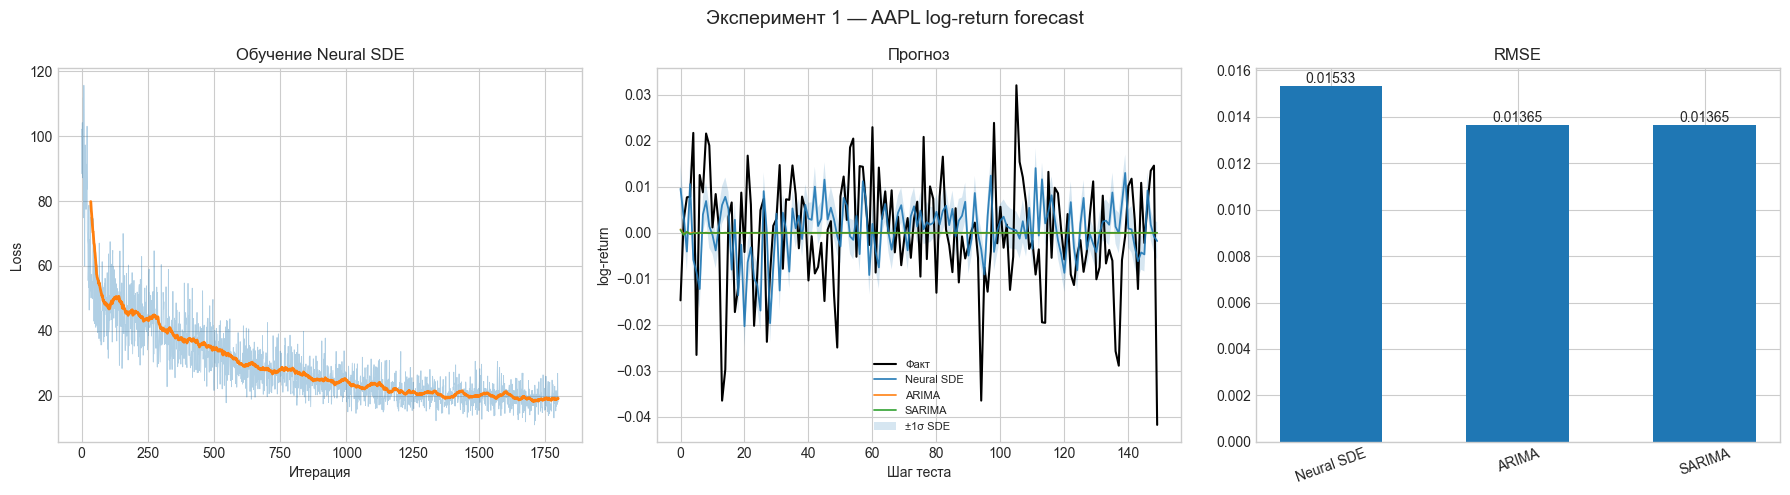

In [11]:
preds_aapl = {
    "Neural SDE": nsde_pred_aapl,
    "ARIMA": arima_pred_aapl,
    "SARIMA": sarima_pred_aapl,
}
metrics_aapl = print_metrics(y_test_aapl, preds_aapl)
plot_experiment(
    "Эксперимент 1 — AAPL log-return forecast",
    losses_aapl,
    y_test_aapl,
    preds_aapl,
    ci=(nsde_lo_aapl, nsde_hi_aapl),
    plot_n=150,
    ylabel="log-return",
)

## Эксперимент 2: потребление электроэнергии

Берем датасет UCI `Individual household electric power consumption`. Ряд агрегируется до дневного потребления, затем прогнозируется следующий день по двум неделям истории, календарным признакам и rolling-статистикам.

In [20]:
POWER_PATH = Path("kt3/household_power_consumption.txt")
if not POWER_PATH.exists():
    POWER_PATH = Path("household_power_consumption.txt")

df_raw = pd.read_csv(
    POWER_PATH,
    sep=";",
    na_values="?",
    low_memory=False,
)

df_raw["datetime"] = pd.to_datetime(
    df_raw["Date"] + " " + df_raw["Time"],
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce",
)

df_raw["Global_active_power"] = pd.to_numeric(
    df_raw["Global_active_power"],
    errors="coerce",
)

df_raw = (
    df_raw
    .dropna(subset=["datetime", "Global_active_power"])
    .sort_values("datetime")
)

daily = df_raw.set_index("datetime")["Global_active_power"].resample("D").sum()
daily = daily[daily > 10]

series_energy = daily.values.astype(np.float32)

print("Energy days:", len(series_energy), daily.index.min(), daily.index.max())

Energy days: 1433 2006-12-16 00:00:00 2010-11-26 00:00:00


In [22]:
WINDOW_E = 14
log_energy = np.log1p(series_energy)

contexts_e, targets_e = [], []
for i in range(len(log_energy) - WINDOW_E - 1):
    past = log_energy[i:i + WINDOW_E]
    day_idx = i + WINDOW_E
    dow = day_idx % 7
    month = (day_idx // 30) % 12

    extra = np.array([
        np.sin(2 * np.pi * dow / 7),
        np.cos(2 * np.pi * dow / 7),
        np.sin(2 * np.pi * month / 12),
        np.cos(2 * np.pi * month / 12),
        past.mean(),
        past.std() + 1e-6,
    ], dtype=np.float32)
    contexts_e.append(np.concatenate([past, extra]).astype(np.float32))
    targets_e.append(log_energy[i + WINDOW_E])

X_energy = np.array(contexts_e, dtype=np.float32)
y_energy_log = np.array(targets_e, dtype=np.float32)

n_train_e = int(len(X_energy) * TRAIN_RATIO)
X_train_e_raw, X_test_e_raw = X_energy[:n_train_e], X_energy[n_train_e:]
y_train_e_raw, y_test_e_log = y_energy_log[:n_train_e], y_energy_log[n_train_e:]

xsc_e = StandardScaler()
ysc_e = StandardScaler()
X_train_e = xsc_e.fit_transform(X_train_e_raw)
X_test_e = xsc_e.transform(X_test_e_raw)
y_train_e = ysc_e.fit_transform(y_train_e_raw.reshape(-1, 1)).ravel()

print("Energy shapes:", X_train_e.shape, X_test_e.shape)

Energy shapes: (1134, 20) (284, 20)


In [23]:
sarima_energy = SARIMAX(
    y_train_e_raw,
    order=(2, 0, 2),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)
sarima_pred_energy_log = np.asarray(sarima_energy.forecast(len(y_test_e_log)))

In [24]:
energy_net, losses_energy = train_nsde(
    X_train_e,
    y_train_e,
    hidden=128,
    activation="silu",
    n_iter=N_ITER_ENERGY,
    lr=3e-4,
    batch_size=BATCH_SIZE,
    obs_std=0.05,
    beta_max=0.05,
)

nsde_pred_energy_log, nsde_lo_energy_log, nsde_hi_energy_log = predict_nsde(energy_net, X_test_e, ysc_e)

# Возвращаемся из log1p в исходную шкалу.
y_test_energy = np.expm1(y_test_e_log)
nsde_pred_energy = np.expm1(nsde_pred_energy_log)
nsde_lo_energy = np.expm1(nsde_lo_energy_log)
nsde_hi_energy = np.expm1(nsde_hi_energy_log)
sarima_pred_energy = np.expm1(sarima_pred_energy_log)

100%|██████████| 1800/1800 [00:38<00:00, 46.62it/s]


,model,RMSE,MAE,MAPE%
0,Neural SDE,379.455536,269.551544,29.441681
1,SARIMA,908.465642,797.030784,94.021917


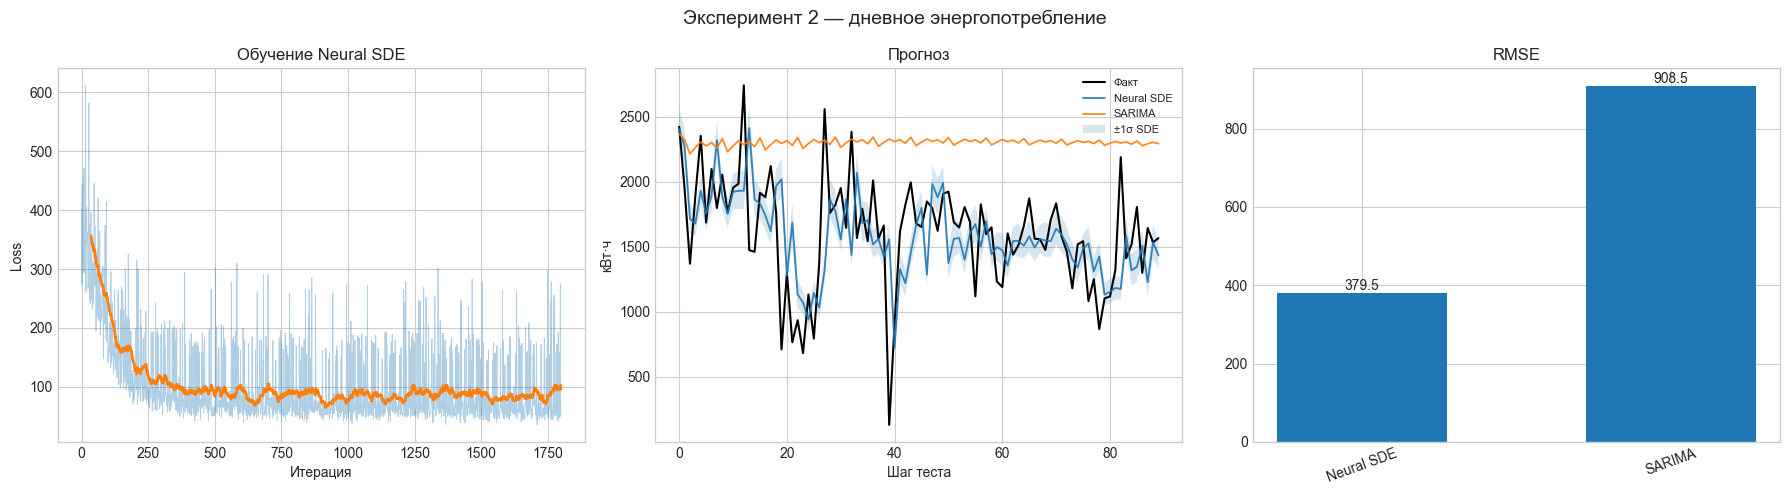

In [25]:
preds_energy = {
    "Neural SDE": nsde_pred_energy,
    "SARIMA": sarima_pred_energy,
}
metrics_energy = print_metrics(y_test_energy, preds_energy)
plot_experiment(
    "Эксперимент 2 — дневное энергопотребление",
    losses_energy,
    y_test_energy,
    preds_energy,
    ci=(nsde_lo_energy, nsde_hi_energy),
    plot_n=90,
    ylabel="кВт·ч",
)

## Эксперимент 3: скачки глюкозы/инсулина

В папке `kt3/data` лежат XML-файлы с CGM-событиями. Внутри есть `glucose_level`, а также дополнительные события пациента. Для задачи скачков используем целевой ряд `glucose_level`: модель прогнозирует следующее значение глюкозы по окну прошлых измерений, скорости изменения, времени суток и индикатору резкого скачка.

Скачок задаем как изменение глюкозы больше `SPIKE_THRESHOLD` мг/дл за один шаг CGM.

In [30]:
DATA_DIR = Path("/Users/morisuhova/Desktop/neural-sde-project/kt3/data")
SPIKE_THRESHOLD = 25.0
WINDOW_G = 24  # примерно 2 часа при шаге CGM 5 минут


def parse_glucose_xml(path):
    root = ET.parse(path).getroot()
    patient_id = root.attrib.get("id", path.stem)
    rows = []
    glucose_node = root.find("glucose_level")
    if glucose_node is None:
        return pd.DataFrame(columns=["patient_id", "datetime", "glucose"])

    for event in glucose_node.findall("event"):
        rows.append({
            "patient_id": patient_id,
            "datetime": pd.to_datetime(event.attrib.get("ts"), format="%d-%m-%Y %H:%M:%S", errors="coerce"),
            "glucose": pd.to_numeric(event.attrib.get("value"), errors="coerce"),
        })
    return pd.DataFrame(rows)


glucose_frames = [parse_glucose_xml(p) for p in sorted(DATA_DIR.glob("*-ws-training.xml"))]
glucose_df = pd.concat(glucose_frames, ignore_index=True)
glucose_df = glucose_df.dropna(subset=["datetime", "glucose"]).sort_values(["patient_id", "datetime"])
glucose_df["glucose"] = glucose_df["glucose"].astype(float)

print("Patients:", glucose_df["patient_id"].nunique())
print("Rows:", len(glucose_df))
display(glucose_df.head())

Patients: 6
Rows: 69255


,patient_id,datetime,glucose
0,559,2021-12-07 01:17:00,101.0
1,559,2021-12-07 01:22:00,98.0
2,559,2021-12-07 01:27:00,104.0
3,559,2021-12-07 01:32:00,112.0
4,559,2021-12-07 01:37:00,120.0


In [31]:
def build_glucose_dataset(df, window=WINDOW_G, spike_threshold=SPIKE_THRESHOLD):
    contexts, targets, meta = [], [], []

    for patient_id, g in df.groupby("patient_id"):
        g = g.sort_values("datetime").reset_index(drop=True)
        values = g["glucose"].values.astype(np.float32)
        times = g["datetime"]
        if len(values) <= window + 1:
            continue

        # Нормализация внутри пациента: так модель учится форме скачков, а не только разнице базовых уровней.
        patient_mean = values.mean()
        patient_std = values.std() + 1e-6
        z = (values - patient_mean) / patient_std
        dz = np.diff(values, prepend=values[0])

        for i in range(len(values) - window - 1):
            past_z = z[i:i + window]
            past_delta = dz[i:i + window]
            j = i + window - 1
            ts = times.iloc[j]
            minute_of_day = ts.hour * 60 + ts.minute
            tod_sin = np.sin(2 * np.pi * minute_of_day / 1440)
            tod_cos = np.cos(2 * np.pi * minute_of_day / 1440)
            spike_flag = float(np.max(np.abs(past_delta)) >= spike_threshold)
            slope = (values[j] - values[max(0, j - 3)]) / max(1, min(3, j))

            extra = np.array([
                np.mean(past_z),
                np.std(past_z) + 1e-6,
                np.max(past_delta),
                np.min(past_delta),
                slope,
                tod_sin,
                tod_cos,
                spike_flag,
                patient_mean / 300.0,
                patient_std / 100.0,
            ], dtype=np.float32)
            contexts.append(np.concatenate([past_z, extra]).astype(np.float32))
            targets.append(z[i + window])
            meta.append({"patient_id": patient_id, "datetime": times.iloc[i + window], "mean": patient_mean, "std": patient_std})

    return np.array(contexts, dtype=np.float32), np.array(targets, dtype=np.float32), pd.DataFrame(meta)


X_glucose, y_glucose_z, meta_glucose = build_glucose_dataset(glucose_df)

# Временное разбиение: первые 80% окон каждого пациента в train, последние 20% в test.
train_idx, test_idx = [], []
for patient_id, idxs in meta_glucose.groupby("patient_id").groups.items():
    idxs = np.array(list(idxs))
    split = int(len(idxs) * TRAIN_RATIO)
    train_idx.extend(idxs[:split])
    test_idx.extend(idxs[split:])
train_idx = np.array(train_idx)
test_idx = np.array(test_idx)

X_train_g_raw, X_test_g_raw = X_glucose[train_idx], X_glucose[test_idx]
y_train_g_raw, y_test_g_z = y_glucose_z[train_idx], y_glucose_z[test_idx]
meta_test_g = meta_glucose.iloc[test_idx].reset_index(drop=True)

xsc_g = StandardScaler()
ysc_g = StandardScaler()
X_train_g = xsc_g.fit_transform(X_train_g_raw)
X_test_g = xsc_g.transform(X_test_g_raw)
y_train_g = ysc_g.fit_transform(y_train_g_raw.reshape(-1, 1)).ravel()

print("Glucose shapes:", X_train_g.shape, X_test_g.shape)

Glucose shapes: (55281, 34) (13824, 34)


In [32]:
# Baseline для CGM: persistence и ARIMA по z-значениям всех train-окон.
persistence_pred_g_z = X_test_g_raw[:, WINDOW_G - 1]

arima_g = SARIMAX(
    y_train_g_raw,
    order=(2, 0, 2),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)
arima_pred_g_z = np.asarray(arima_g.forecast(len(y_test_g_z)))

In [33]:
glucose_net, losses_glucose = train_nsde(
    X_train_g,
    y_train_g,
    hidden=128,
    activation="silu",
    n_iter=N_ITER_INSULIN,
    lr=5e-4,
    batch_size=BATCH_SIZE,
    obs_std=0.08,
    beta_max=0.04,
)

nsde_pred_g_z_scaled, nsde_lo_g_z_scaled, nsde_hi_g_z_scaled = predict_nsde(glucose_net, X_test_g, ysc_g)

# Перевод из пациентского z-score в мг/дл.
def glucose_from_z(z_values, meta):
    return np.asarray(z_values) * meta["std"].values + meta["mean"].values


y_test_glucose = glucose_from_z(y_test_g_z, meta_test_g)
nsde_pred_glucose = glucose_from_z(nsde_pred_g_z_scaled, meta_test_g)
nsde_lo_glucose = glucose_from_z(nsde_lo_g_z_scaled, meta_test_g)
nsde_hi_glucose = glucose_from_z(nsde_hi_g_z_scaled, meta_test_g)
persistence_pred_glucose = glucose_from_z(persistence_pred_g_z, meta_test_g)
arima_pred_glucose = glucose_from_z(arima_pred_g_z, meta_test_g)

100%|██████████| 1800/1800 [00:40<00:00, 45.00it/s]


,model,RMSE,MAE,MAPE%
0,Neural SDE,7.436593,3.777947,2.528207
1,Persistence,7.750817,4.168620,2.785822
2,ARIMA,58.337133,46.057543,32.569322


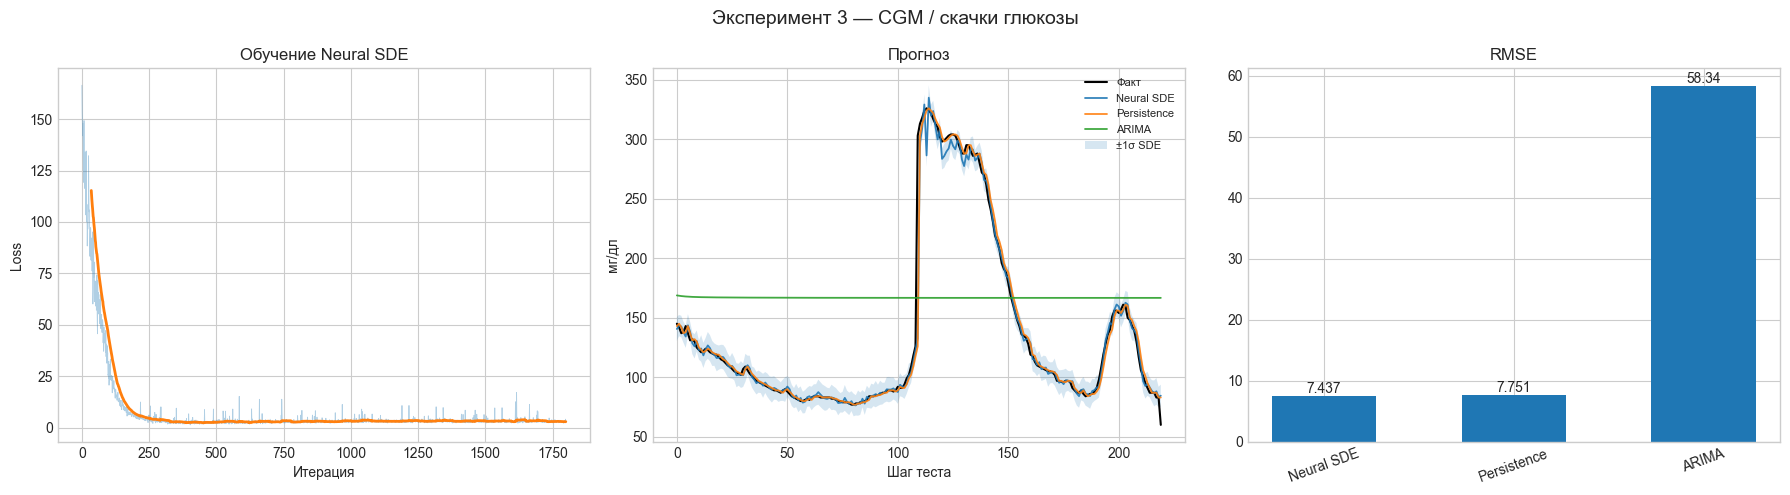

In [34]:
preds_glucose = {
    "Neural SDE": nsde_pred_glucose,
    "Persistence": persistence_pred_glucose,
    "ARIMA": arima_pred_glucose,
}
metrics_glucose = print_metrics(y_test_glucose, preds_glucose)
plot_experiment(
    "Эксперимент 3 — CGM / скачки глюкозы",
    losses_glucose,
    y_test_glucose,
    preds_glucose,
    ci=(nsde_lo_glucose, nsde_hi_glucose),
    plot_n=220,
    ylabel="мг/дл",
)

In [35]:
# Отдельно смотрим качество на резких изменениях в тесте.
true_delta_test = np.diff(y_test_glucose, prepend=y_test_glucose[0])
spike_mask = np.abs(true_delta_test) >= SPIKE_THRESHOLD

print(f"Spike points in test: {spike_mask.sum()} / {len(spike_mask)}")
if spike_mask.sum() > 0:
    spike_metrics = print_metrics(
        y_test_glucose[spike_mask],
        {name: np.asarray(pred)[spike_mask] for name, pred in preds_glucose.items()},
    )
else:
    print("В тестовой части нет точек, проходящих порог скачка. Уменьшите SPIKE_THRESHOLD для отдельной оценки.")

Spike points in test: 130 / 13824


,model,RMSE,MAE,MAPE%
0,Neural SDE,56.540527,41.928089,23.463379
1,Persistence,57.693153,43.561539,24.497053
2,ARIMA,80.326904,60.578886,30.574918


## Сводная таблица

После запуска всех ячеек здесь собираются RMSE/MAE/MAPE по трем доменам. Масштабы разные, поэтому сравнивать числа между доменами напрямую нельзя; внутри каждого домена сравниваются модели на одной шкале.

In [36]:
summary = pd.concat(
    [
        metrics_aapl.assign(domain="AAPL"),
        metrics_energy.assign(domain="Energy"),
        metrics_glucose.assign(domain="CGM glucose spikes"),
    ],
    ignore_index=True,
)
summary = summary[["domain", "model", "RMSE", "MAE", "MAPE%"]]
display(summary)

,domain,model,RMSE,MAE,MAPE%
0,AAPL,ARIMA,0.013650,0.010135,99.736440
1,AAPL,SARIMA,0.013651,0.010137,99.760951
2,AAPL,Neural SDE,0.015325,0.011733,108133.523438
3,Energy,Neural SDE,379.455536,269.551544,29.441681
4,Energy,SARIMA,908.465642,797.030784,94.021917
5,CGM glucose spikes,Neural SDE,7.436593,3.777947,2.528207
6,CGM glucose spikes,Persistence,7.750817,4.168620,2.785822
7,CGM glucose spikes,ARIMA,58.337133,46.057543,32.569322


Neural SDE особенно хорош там где есть нелинейная стохастическая динамика — глюкоза и энергетика. Для финансов (почти белый шум) классические модели не уступают.